## Import Libraries

In [63]:
import sys
import os
import json
import torch
import gpytorch
import numpy as np
import datetime
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split


## source file and folders

In [64]:

try:
    current_dir = os.getcwd()
except:
    current_dir = os.path.dirname(os.path.abspath(__file__))

training_data_dir = os.path.join(current_dir, '../training_data', 'paramteric_dataset')
solver_dir = os.path.join(current_dir, '../training_data')
model_dir = os.path.join(current_dir, '../model')
model_trained_dir = os.path.join(current_dir, '../model_trained')
sys.path.insert(0,str(training_data_dir))
sys.path.insert(0,str(model_dir))
sys.path.insert(0,str(solver_dir))

from simdata_mush_dirc_icc import  *
from model import *

def set_seed(seed):
    # Set random seeds for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    os.environ["PYTHONHASHSEED"] = str(seed)

    # Use deterministic algorithms
    torch.use_deterministic_algorithms(True)

    # This may not exist on macOS if not using GPU or CuDNN
    if torch.backends.mps.is_available():  # MPS = Apple GPU backend
        print("Using Apple Metal Performance Shaders (MPS)")
    elif torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        print("Using CuDNN for GPU acceleration")
    else:
        print("Using CPU or no GPU acceleration")

set_seed(1234)

Using CuDNN for GPU acceleration


## Source and load training data

In [65]:
# import data from training_data directory

# load the data from simulated data csv file
data_path = os.path.join(training_data_dir, 'simulated_dataset.csv')

data = np.loadtxt(data_path, delimiter=',', skiprows=1) # Load data from CSV file
input_data = data[:, :-1]  # All columns except the last one
temp_data = data[:, -1]  # Last column


### Scale data using Min MaxScaler

#### Scale output/target

In [66]:
temp_data = temp_data.flatten()

scaler_temp = MinMaxScaler()

temp_scaled = scaler_temp.fit_transform(temp_data.reshape(-1, 1))
print(temp_scaled.max(), temp_scaled.min())




1.0 0.0


#### Scale input data

In [67]:
scaler_input = MinMaxScaler()
input_scaled = scaler_input.fit_transform(input_data)


In [68]:
data_x = torch.tensor(input_scaled, dtype=torch.float32)
data_y = torch.tensor(temp_scaled, dtype=torch.float32)
indices = np.arange(len(data_x))

train_x, test_x, train_y, test_y, index_train, index_test = train_test_split(data_x, data_y, indices, test_size=0.2, random_state=42)

subset_size = 5 # here we define the size of the subset we want to use for training and testing
subset_indices = np.random.choice(np.arange(len(train_x)), size=subset_size, replace=False)

train_x_subset = train_x[subset_indices]
train_y_subset = train_y[subset_indices].squeeze(-1)

subset_test_indices = np.random.choice(np.arange(len(test_x)), size=subset_size, replace=False)
test_x_subset = test_x[subset_test_indices]
test_y_subset = test_y[subset_test_indices].squeeze(-1)

print("Train subset shape:", train_x_subset.shape, train_y_subset.shape)

Train subset shape: torch.Size([5, 5]) torch.Size([5])


## Model Definition

In [69]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x_subset, train_y_subset, likelihood)

## Model training

In [70]:
# train the model

model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)  # Includes GaussianLikelihood parameters
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

num_epochs = 10 # here is the number of epochs you want to train for
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(train_x_subset)
    loss = -mll(output, train_y_subset)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item()}')

Epoch 1/10, Loss: 1.0461132526397705


## Model testing and evaluation

In [71]:
# test the model
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    
    observed_pred = likelihood(model(test_x_subset))
    mean = scaler_temp.inverse_transform(observed_pred.mean.reshape(-1, 1))
    lower, upper = observed_pred.confidence_region()
    lower = scaler_temp.inverse_transform(lower.reshape(-1, 1))
    upper = scaler_temp.inverse_transform(upper.reshape(-1, 1))


In [72]:
test_y_scaled = scaler_temp.inverse_transform(test_y_subset.reshape(-1, 1))

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(test_y_scaled, mean)
r2 = r2_score(test_y_scaled, mean)
print(f"MSE: {mse:.4f}, R²: {r2:.4f}")


MSE: 9579.1326, R²: -0.1953


In [ ]:
# save the model in model directory and save the  metrics in a text file


if not os.path.exists(model_trained_dir):
    os.makedirs(model_trained_dir)
# create a new directory with the current date and time for storing the model
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_save_dir = os.path.join(model_trained_dir, f"model_{current_time}")
os.makedirs(model_save_dir, exist_ok=True)
model_save_path = os.path.join(model_save_dir, 'model.pth')

# save the scalers 
scaler_input_path = os.path.join(model_save_dir, 'scaler_input.pkl')
scaler_temp_path = os.path.join(model_save_dir, 'scaler_temp.pkl')
import joblib
joblib.dump(scaler_input, scaler_input_path)
joblib.dump(scaler_temp, scaler_temp_path)

# log metrics and other details in overview.txt


metrics_save_path = os.path.join(model_save_dir, 'overview.txt')
with open(metrics_save_path, 'w') as f:
    f.write(f"Date and Time: {current_time}\n")
    f.write(f"Number of Epochs: {num_epochs}\n")
    f.write(f"Subset Size: {subset_size}\n")    
    f.write(f"MSE: {mse:.4f}\n")
    f.write(f"R²: {r2:.4f}\n")
    f.write(f"RMSE Left: {rmse_l:.4f}\n")
    f.write(f"RMSE Right: {rmse_r:.4f}\n")
    f.write(f"RMSE Middle: {rmse_m:.4f}\n")
torch.save(model.state_dict(), model_save_path)

(5, 1) (5, 1) (5, 1)


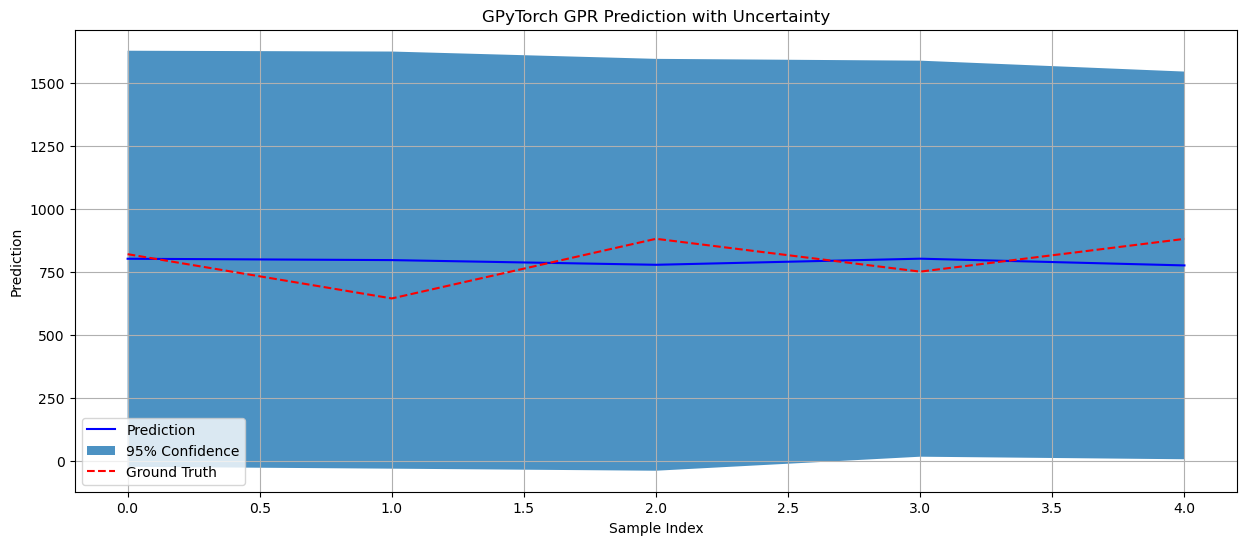

In [74]:
x = range(len(mean))  # or test_x if it's 1D
print(mean.shape, lower.shape, upper.shape)
plt.figure(figsize=(15,6))
plt.plot(x, mean, 'b', label='Prediction')
plt.fill_between(x, lower.squeeze(-1), upper.squeeze(-1), alpha=0.8, label='95% Confidence')
plt.plot(x, test_y_scaled, 'r--', label='Ground Truth')
plt.legend()
plt.title("GPyTorch GPR Prediction with Uncertainty")
plt.xlabel("Sample Index")
plt.ylabel("Prediction")
plt.grid()
plt.show()

In [75]:
# plot the input to prediction and generate 2D plot

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    total_x = torch.tensor(data_x, dtype=torch.float32)
    total_y = torch.tensor(temp_scaled, dtype=torch.float32)
    
    pred_x = model(total_x)
    observed_pred = likelihood(pred_x)
    mean = scaler_temp.inverse_transform(observed_pred.mean.reshape(-1, 1))
    lower, upper = observed_pred.confidence_region()
    lower = scaler_temp.inverse_transform(lower.reshape(-1, 1))
    upper = scaler_temp.inverse_transform(upper.reshape(-1, 1))
    total_y_scaled = scaler_temp.inverse_transform(total_y.reshape(-1, 1))
    print(mean.shape, lower.shape, upper.shape)

/tmp/ipykernel_1013391/3294471055.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  total_x = torch.tensor(data_x, dtype=torch.float32)


(100000, 1) (100000, 1) (100000, 1)


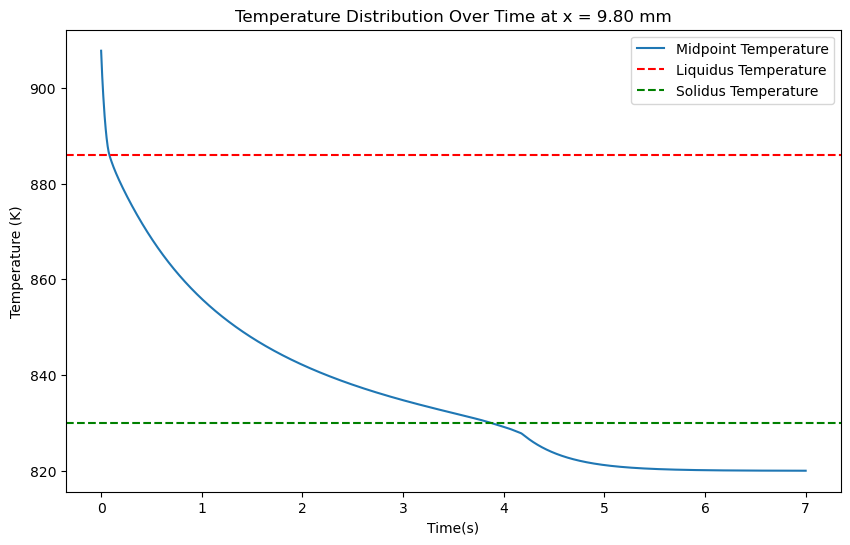

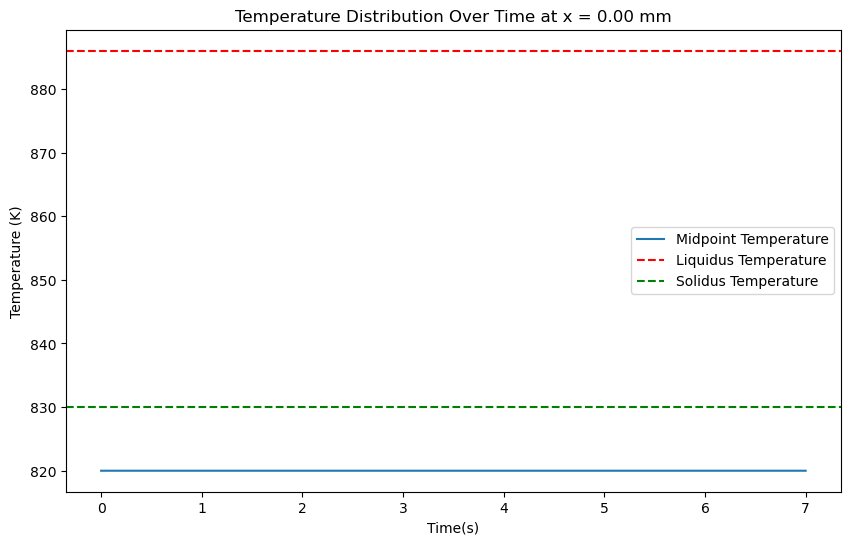

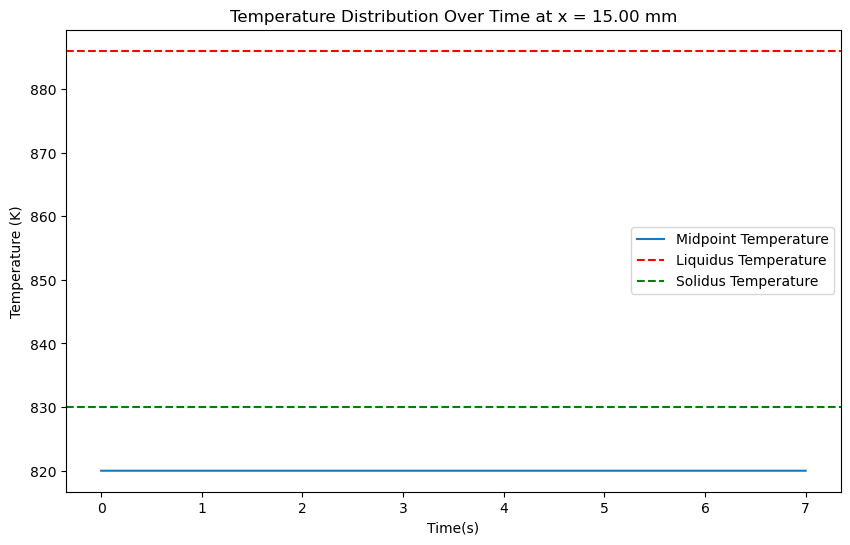

In [76]:
settings_path_1 = os.path.join(current_dir, '../training_data', 'settings.json')
with open(settings_path_1,'r') as file:
    settings = json.load(file)


heat_data = HT_sim(settings)
alpha = heat_data.alpha_l
tempfield = heat_data.datagen()

heat_data.plot_temp(32)
dt = heat_data.dt
dx = heat_data.dx
# print(heat_data.dx)
# print(dt)
settings_path = os.path.join(current_dir, '../training_data', 'settings.json')
with open(settings_path,'r') as file:
    props = json.load(file)

heat_data.plot_temp(0)
heat_data.plot_temp(50-1)

In [77]:
# get temperature at boundaries and at center
time_end = props['time_end']
timesteps = int(time_end / dt) + 1  # +1 to include the
t = np.linspace(0, time_end, 10)
# random sample from the t
# t_sim = np.random.choice(t, size=10, replace=False)
length = props['length']
x_l = np.zeros_like(t)
x_r = np.ones_like(t) * length
x_m = np.ones_like(t) * (length / 2)
print(t)

[0.         0.77777778 1.55555556 2.33333333 3.11111111 3.88888889
 4.66666667 5.44444444 6.22222222 7.        ]


In [78]:

temps_l = [temp_at_pt(heat_data, x, t) for x, t in zip(x_l, t)]
temps_r = [temp_at_pt(heat_data, x, t) for x, t in zip(x_r, t)]
temps_m = [temp_at_pt(heat_data, x, t) for x, t in zip(x_m, t)]

print(temps_m)

[np.float64(918.9491354038681), np.float64(865.3044502572436), np.float64(850.1683355003302), np.float64(841.5445063401115), np.float64(835.956169798053), np.float64(831.7896050384462), np.float64(822.8769545701142), np.float64(820.4867245599762), np.float64(820.0823448188395), np.float64(820.013920717892)]


In [79]:
l_fusion = np.ones_like(t) * props['L_fusion']
die_temp_l = np.ones_like(t) * props['die_temp_l']
die_temp_r = np.ones_like(t) * props['die_temp_r']

inp_l = np.stack((x_l, t, l_fusion, die_temp_l, die_temp_r), axis=1)
inp_r = np.stack((x_r, t, l_fusion, die_temp_l, die_temp_r), axis=1)
inp_m = np.stack((x_m, t, l_fusion, die_temp_l, die_temp_r), axis=1)



In [80]:
# scale inputs

inp_l_scaled = scaler_input.transform(inp_l)
inp_r_scaled = scaler_input.transform(inp_r)
inp_m_scaled = scaler_input.transform(inp_m)

# predict the outputs 

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    inp_l_tensor = torch.tensor(inp_l_scaled, dtype=torch.float32)
    inp_r_tensor = torch.tensor(inp_r_scaled, dtype=torch.float32)
    inp_m_tensor = torch.tensor(inp_m_scaled, dtype=torch.float32)

    pred_l = model(inp_l_tensor)
    pred_r = model(inp_r_tensor)
    pred_m = model(inp_m_tensor)

    observed_pred_l = likelihood(pred_l)
    observed_pred_r = likelihood(pred_r)
    observed_pred_m = likelihood(pred_m)

    mean_l = scaler_temp.inverse_transform(observed_pred_l.mean.reshape(-1, 1))
    mean_r = scaler_temp.inverse_transform(observed_pred_r.mean.reshape(-1, 1))
    mean_m = scaler_temp.inverse_transform(observed_pred_m.mean.reshape(-1, 1))

    lower_l, upper_l = observed_pred_l.confidence_region()
    lower_r, upper_r = observed_pred_r.confidence_region()
    lower_m, upper_m = observed_pred_m.confidence_region()
    lower_l = scaler_temp.inverse_transform(lower_l.reshape(-1, 1))
    upper_l = scaler_temp.inverse_transform(upper_l.reshape(-1, 1))
    lower_r = scaler_temp.inverse_transform(lower_r.reshape(-1, 1))
    upper_r = scaler_temp.inverse_transform(upper_r.reshape(-1, 1))
    lower_m = scaler_temp.inverse_transform(lower_m.reshape(-1, 1))
    upper_m = scaler_temp.inverse_transform(upper_m.reshape(-1, 1))
    

In [81]:
# calcualte rmse
rmse_l = np.sqrt(np.mean((mean_l - temps_l) ** 2))
rmse_r = np.sqrt(np.mean((mean_r - temps_r) ** 2))
rmse_m = np.sqrt(np.mean((mean_m - temps_m) ** 2))
print(f"RMSE Left: {rmse_l:.4f}, Right: {rmse_r:.4f}, Middle: {rmse_m:.4f}")



RMSE Left: 32.1556, Right: 32.5180, Middle: 63.7071


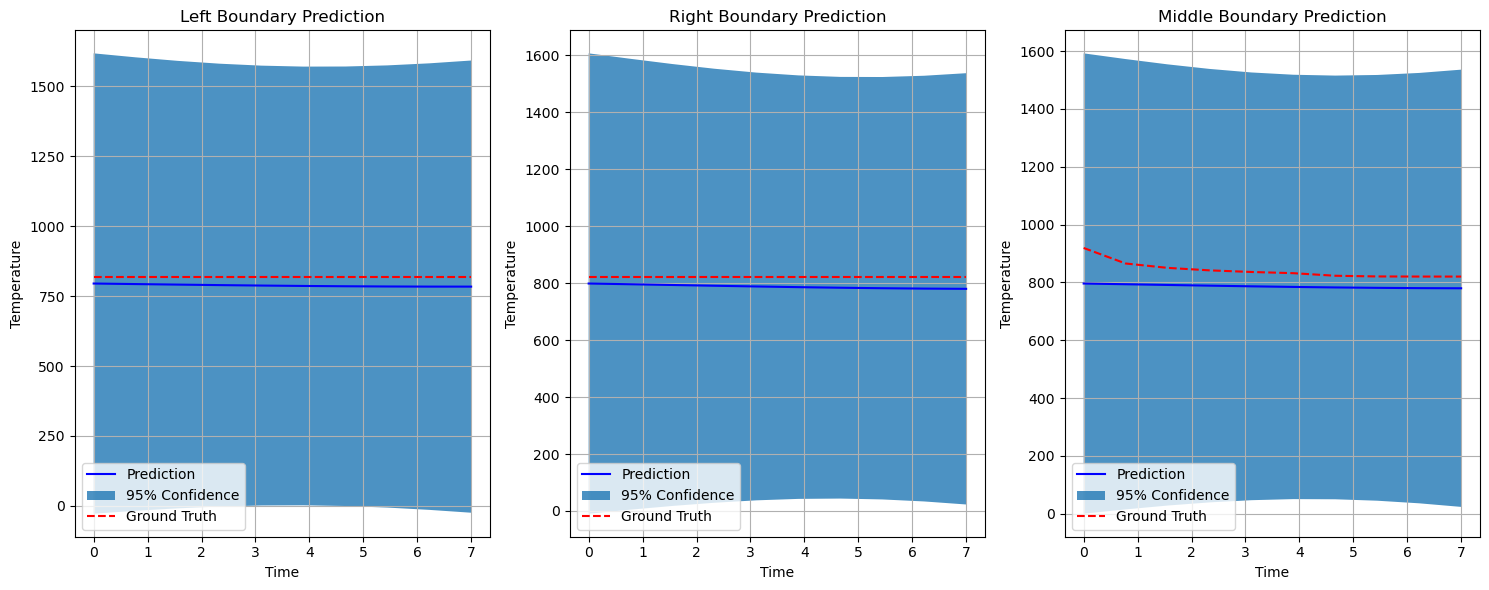

In [82]:
# plot the results for left, right and middle
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.plot(t, mean_l, 'b', label='Prediction')
plt.fill_between(t, lower_l.squeeze(-1), upper_l.squeeze(-1), alpha
=0.8, label='95% Confidence')
plt.plot(t, temps_l, 'r--', label='Ground Truth')
plt.title("Left Boundary Prediction")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
plt.subplot(1, 3, 2)
plt.plot(t, mean_r, 'b', label='Prediction')
plt.fill_between(t, lower_r.squeeze(-1), upper_r.squeeze(-1), alpha=0.8, label='95% Confidence')
plt.plot(t, temps_r, 'r--', label='Ground Truth')
plt.title("Right Boundary Prediction")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
plt.subplot(1, 3, 3)
plt.plot(t, mean_m, 'b', label='Prediction')
plt.fill_between(t, lower_m.squeeze(-1), upper_m.squeeze(-1), alpha=0.8, label='95% Confidence')
plt.plot(t, temps_m, 'r--', label='Ground Truth')
plt.title("Middle Boundary Prediction")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()  
